# Trust Model - Model Comparison Analysis

In [1]:
import sys
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트로 작업 디렉토리 변경
current_dir = Path(os.getcwd())
if 'apps' in str(current_dir):
    try:
        project_root = current_dir.parent.parent
        os.chdir(project_root)
        print(f"📂 작업 디렉토리를 변경했습니다: {os.getcwd()}")
    except Exception as e:
        print(f"⚠️ 작업 디렉토리 변경 실패: {e}")
else:
    print(f"📂 현재 작업 디렉토리: {os.getcwd()}")

📂 작업 디렉토리를 변경했습니다: c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM


In [2]:
# 데이터 및 기존 모델 로드
model_path = 'apps/reco/trust_model/final_trust_model.pkl'
X_test_path = 'data/ML/trust/X_test.csv'
y_test_path = 'data/ML/trust/y_test.csv'
X_train_path = 'data/ML/trust/X_train.csv'
y_train_path = 'data/ML/trust/y_train.csv'

if os.path.exists(model_path) and os.path.exists(X_test_path):
    print("✅ 데이터 로드 중...")
    
    # 1. 모델 번들 로드
    with open(model_path, 'rb') as f:
        model_bundle = pickle.load(f)
    
    logistic_model = model_bundle['model']
    scaler = model_bundle['scaler']
    feature_names = model_bundle.get('feature_names', [])
    
    # 2. 데이터 로드
    X_train = pd.read_csv(X_train_path)
    y_train = pd.read_csv(y_train_path)
    X_test = pd.read_csv(X_test_path)
    y_test = pd.read_csv(y_test_path)
    
    # Series 변환
    if isinstance(y_test, pd.DataFrame): y_test = y_test.iloc[:, 0]
    if isinstance(y_train, pd.DataFrame): y_train = y_train.iloc[:, 0]
    
    # 스케일링
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 가중치 조정 (총거래활동량_log)
    if "총거래활동량_log" in list(X_test.columns):
        idx = list(X_test.columns).index("총거래활동량_log")
        X_train_scaled[:, idx] *= 0.5
        X_test_scaled[:, idx] *= 0.5
        print("   ✅ '총거래활동량_log' Feature 가중치 0.5배 적용 완료")
        
    print(f"   - Train Data: {X_train.shape}")
    print(f"   - Test Data: {X_test.shape}")
    
else:
    print("⚠️ 모델 또는 데이터 파일이 없습니다. graph.ipynb를 먼저 실행하여 파이프라인을 완료해주세요.")

✅ 데이터 로드 중...
   ✅ '총거래활동량_log' Feature 가중치 0.5배 적용 완료
   - Train Data: (280, 14)
   - Test Data: (70, 14)


In [3]:
# 모델 및 교차검증 전략 설정
if 'logistic_model' in locals():
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, f1_score
    from sklearn.model_selection import cross_val_score, StratifiedKFold

    # 비교할 모델 정의
    # (매번 재생성하여 학습 간섭 방지)
    def get_models():
        models = {
            "LogisticRegression": logistic_model,
            "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
        }
        
        # XGBoost (Optional)
        try:
            from xgboost import XGBClassifier
            models["XGBoost"] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
        except ImportError:
            print("⚠️ XGBoost 라이브러리가 설치되지 않아 비교에서 제외됩니다.")
            
        # LightGBM (Optional)
        try:
            from lightgbm import LGBMClassifier
            models["LightGBM"] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
        except ImportError:
            print("⚠️ LightGBM 라이브러리가 설치되지 않아 비교에서 제외됩니다.")
            
        return models

    # CV 전략 정의 (학습 코드와 동일하게 설정)
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    print("✅ 모델 및 CV 설정 완료")

✅ 모델 및 CV 설정 완료


## 1. F1-Score & Overfitting Analysis

In [13]:
# [Trust Model] 모델 성능 비교 (LR, RF, XGB, LightGBM)
# Metrics: Train F1, CV Mean F1, Test F1, Gap (Train-Test)

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 추가 라이브러리 체크
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

# 1. 데이터 확인 (Auto-Check)
if 'X_train_scaled' not in locals():
    print("⚠️ 'X_train_scaled' 변수가 없습니다. Trust Model 데이터를 먼저 로드해주세요!")
else:
    # 2. 모델 정의
    trust_models = {
        'LogisticRegression': LogisticRegression(
            C=1, penalty='l1', solver='saga', class_weight='balanced', 
            random_state=42, max_iter=1000
        ),
        'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1)
    }
    
    if XGBClassifier:
        trust_models['XGBoost'] = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
    if LGBMClassifier:
        trust_models['LightGBM'] = LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)

    # 3. 분석 루프
    results_list = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print("📊 Trust Model 다중 모델 비교 분석 시작 (LR, RF, XGB, LGBM)...")

    for name, model in trust_models.items():
        print(f"   👉 Processing {name}...")
        
        # 3.1 Cross Validation (Train F1, CV F1)
        # return_train_score=True를 통해 Train 점수도 확보
        cv_res = cross_validate(model, X_train_scaled, y_train, cv=skf, 
                                scoring='f1_macro', return_train_score=True, n_jobs=-1)
        
        train_f1 = np.mean(cv_res['train_score'])
        cv_f1 = np.mean(cv_res['test_score'])
        
        # 3.2 Hold-out Test Evaluation (Test F1)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        test_f1 = f1_score(y_test, y_pred, average='macro')
        
        # 3.3 Gap Calculation (Train - Test)
        gap = train_f1 - test_f1
        
        results_list.append({
            'Model': name,
            'Train F1': round(train_f1, 4),
            'CV F1': round(cv_f1, 4),
            'Test F1': round(test_f1, 4),
            'Gap (Train-Test)': round(gap, 4)
        })

    # 4. 결과 출력
    df_trust_compare = pd.DataFrame(results_list)
    print("\n[Trust Model Performance Comparison]")
    display(df_trust_compare)

📊 Trust Model 다중 모델 비교 분석 시작 (LR, RF, XGB, LGBM)...
   👉 Processing LogisticRegression...


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


   👉 Processing RandomForest...
   👉 Processing XGBoost...
   👉 Processing LightGBM...

[Trust Model Performance Comparison]


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Train F1,CV F1,Test F1,Gap (Train-Test)
0,LogisticRegression,0.8153,0.7843,0.7267,0.0887
1,RandomForest,1.0000,0.6563,0.6390,0.3610
2,XGBoost,1.0000,0.6791,0.7728,0.2272
3,LightGBM,1.0000,0.7025,0.7297,0.2703


## 2. Accuracy Analysis (정확도 비교)

🚀 Accuracy 비교 분석 시작 (CV 포함)...


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarni

[LogisticRegression] Train: 0.8143 / Test: 0.7286 / CV: 0.7821 / Gap: 0.0857
[RandomForest] Train: 1.0000 / Test: 0.6571 / CV: 0.6536 / Gap: 0.3429
[XGBoost] Train: 1.0000 / Test: 0.7857 / CV: 0.6750 / Gap: 0.2143


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site

[LightGBM] Train: 1.0000 / Test: 0.7571 / CV: 0.6964 / Gap: 0.2429

📊 Accuracy 비교 결과:


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Train Acc,Test Acc,CV Acc,Gap(Acc)
LogisticRegression,0.8143,0.7286,0.7821,0.0857
RandomForest,1.0000,0.6571,0.6536,0.3429
XGBoost,1.0000,0.7857,0.6750,0.2143
LightGBM,1.0000,0.7571,0.6964,0.2429


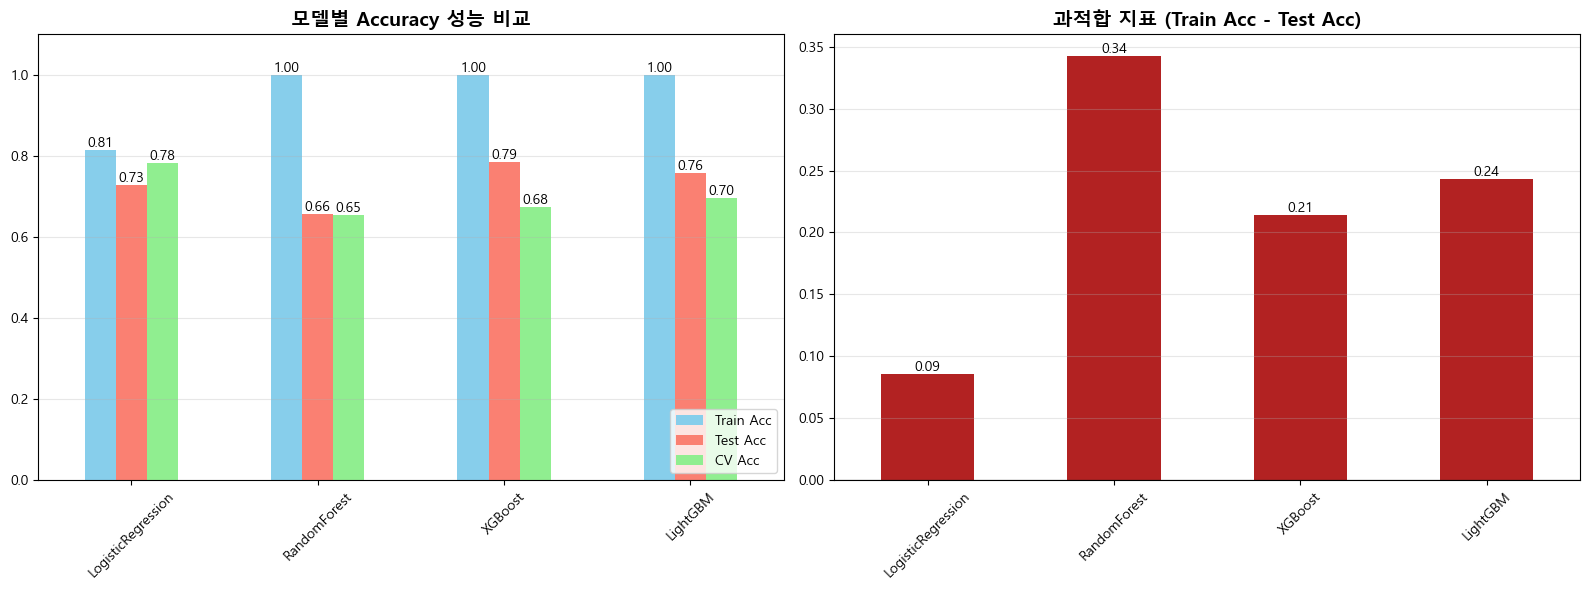

In [10]:
# Accuracy 분석 코드
if 'logistic_model' in locals():
    comparison_models = get_models()
    acc_results = {}

    print("🚀 Accuracy 비교 분석 시작 (CV 포함)...")
    print("="*80)

    for name, clf in comparison_models.items():
        if name != "LogisticRegression":
            clf.fit(X_train_scaled, y_train)
        
        # 예측
        train_pred = clf.predict(X_train_scaled)
        test_pred = clf.predict(X_test_scaled)
        
        # Accuracy 계산
        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        cv_acc_scores = cross_val_score(clf, X_train_scaled, y_train, cv=cv_strategy, scoring='accuracy')
        cv_acc = cv_acc_scores.mean()
        
        # 과적합 Gap (Train Acc - Test Acc)
        gap_acc = train_acc - test_acc
        
        acc_results[name] = {
            'Train Acc': train_acc,
            'Test Acc': test_acc,
            'CV Acc': cv_acc,
            'Gap(Acc)': gap_acc
        }
        
        print(f"[{name}] Train: {train_acc:.4f} / Test: {test_acc:.4f} / CV: {cv_acc:.4f} / Gap: {gap_acc:.4f}")

    # 시각화
    if len(acc_results) > 0:
        acc_df = pd.DataFrame(acc_results).T
        
        print("\n📊 Accuracy 비교 결과:")
        display(acc_df.style.highlight_max(axis=0, color='lightgreen').format("{:.4f}"))

        fig, ax = plt.subplots(1, 2, figsize=(16, 6))

        # Accuracy Comparison
        acc_df[['Train Acc', 'Test Acc', 'CV Acc']].plot(kind='bar', ax=ax[0], color=['skyblue', 'salmon', 'lightgreen'], rot=45)
        ax[0].set_title("모델별 Accuracy 성능 비교", fontsize=14, fontweight='bold')
        ax[0].set_ylim(0, 1.1)
        ax[0].grid(axis='y', alpha=0.3)
        ax[0].legend(loc='lower right')

        # Gap Comparison
        acc_df['Gap(Acc)'].plot(kind='bar', ax=ax[1], color='firebrick', rot=45)
        ax[1].set_title("과적합 지표 (Train Acc - Test Acc)", fontsize=14, fontweight='bold')
        ax[1].axhline(0, color='black', linewidth=0.8)
        ax[1].grid(axis='y', alpha=0.3)
        
        for container in ax[0].containers:
            ax[0].bar_label(container, fmt='%.2f')
        for container in ax[1].containers:
            ax[1].bar_label(container, fmt='%.2f')
            
        plt.tight_layout()
        plt.show()

In [11]:
# Trust_model Accuracy, Precision, Recall, F1 Score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# 예측 수행
y_pred = logistic_model.predict(X_test_scaled)

# 1. 상세 리포트 출력 (Class별 Precision, Recall, F1)
print("📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# 2. 요약 지표 계산 (Macro Average 기준)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("-" * 30)
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall   : {recall:.4f}")
print(f"✅ F1 Score : {f1:.4f}")
print("-" * 30)


📊 Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.6667    0.9474    0.7826        19
           1     0.7931    0.6389    0.7077        36
           2     0.7143    0.6667    0.6897        15

    accuracy                         0.7286        70
   macro avg     0.7247    0.7510    0.7267        70
weighted avg     0.7419    0.7286    0.7242        70

------------------------------
✅ Accuracy : 0.7286
✅ Precision: 0.7247
✅ Recall   : 0.7510
✅ F1 Score : 0.7267
------------------------------


# Logistic Regression Train/Test Accuracy 변화

🚀 Logistic Regression(saga) 학습 곡선 분석 시작 (Loss / Acc / F1)...
Iter 10: Loss=0.4809, Acc=0.8036, F1=0.8064
Iter 20: Loss=0.4511, Acc=0.8071, F1=0.8100


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarni

Iter 30: Loss=0.4413, Acc=0.8143, F1=0.8169
Iter 40: Loss=0.4384, Acc=0.8143, F1=0.8169
Iter 50: Loss=0.4371, Acc=0.8107, F1=0.8137


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarni

Iter 60: Loss=0.4362, Acc=0.8107, F1=0.8137
Iter 70: Loss=0.4352, Acc=0.8143, F1=0.8172
Iter 80: Loss=0.4347, Acc=0.8143, F1=0.8172
Iter 90: Loss=0.4343, Acc=0.8143, F1=0.8172
Iter 100: Loss=0.4340, Acc=0.8143, F1=0.8172


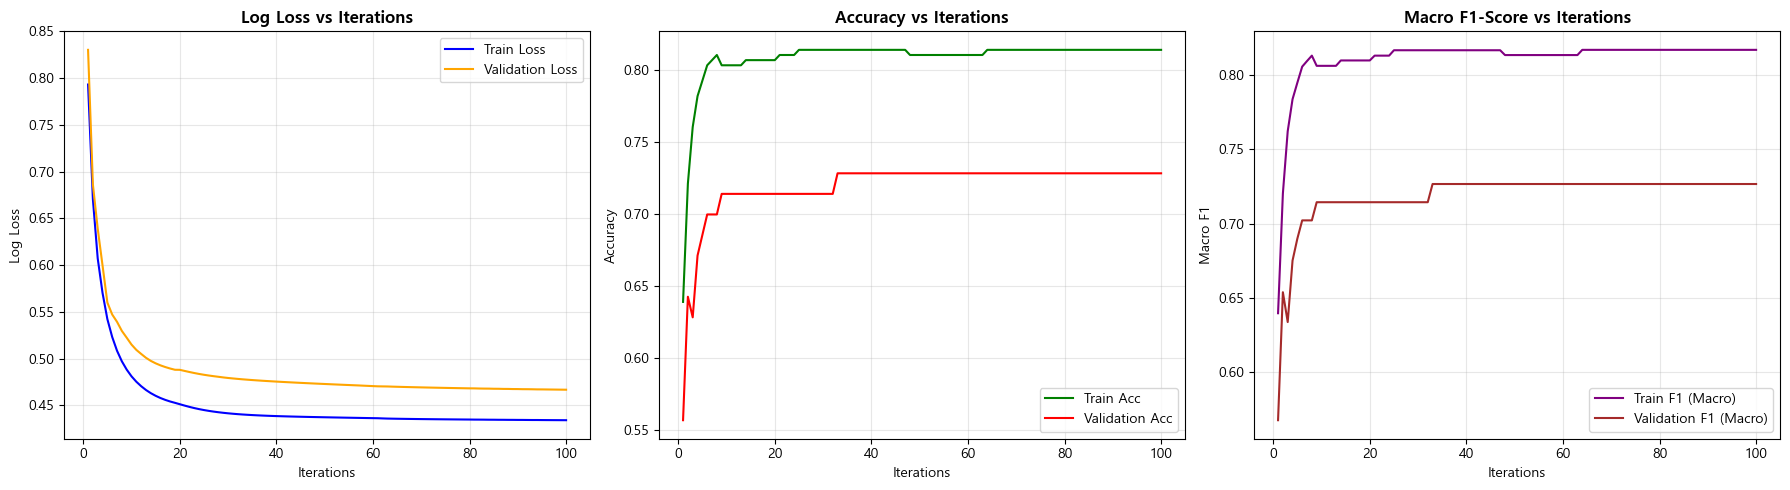

In [14]:
# Logistic Regression 학습 곡선 시각화
# 실제 모델(Volvo 'saga')의 학습 과정을 'Iterations' 기준으로 시각화합니다.
# 시각화 지표: Loss, Accuracy, F1-Score (Macro)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

print("🚀 Logistic Regression(saga) 학습 곡선 분석 시작 (Loss / Acc / F1)...")
print("="*80)

# Warm Start 설정을 통해 Iteration별 학습 진행
lr_viz_model = LogisticRegression(
    C=1,
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    random_state=42,
    warm_start=True,
    max_iter=1 
)

train_losses = []
test_losses = []
train_accs = []
test_accs = []
train_f1s = []
test_f1s = []
iterations = []

# 100 Iterations (saga solver는 매우 빠르게 수렴하므로 100회면 충분히 수렴 과정을 볼 수 있음)
n_iters = 100
for i in range(1, n_iters + 1):
    lr_viz_model.max_iter = i
    lr_viz_model.fit(X_train_scaled, y_train)
    
    # 예측
    train_prob = lr_viz_model.predict_proba(X_train_scaled)
    test_prob = lr_viz_model.predict_proba(X_test_scaled)
    train_pred = lr_viz_model.predict(X_train_scaled)
    test_pred = lr_viz_model.predict(X_test_scaled)
    
    # Loss
    train_losses.append(log_loss(y_train, train_prob))
    test_losses.append(log_loss(y_test, test_prob))
    
    # Accuracy
    train_accs.append(accuracy_score(y_train, train_pred))
    test_accs.append(accuracy_score(y_test, test_pred))
    
    # Macro F1
    train_f1s.append(f1_score(y_train, train_pred, average='macro'))
    test_f1s.append(f1_score(y_test, test_pred, average='macro'))
    
    iterations.append(i)
    
    if i % 10 == 0:
        print(f"Iter {i}: Loss={train_losses[-1]:.4f}, Acc={train_accs[-1]:.4f}, F1={train_f1s[-1]:.4f}")

# 그래프 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss Curve
axes[0].plot(iterations, train_losses, label='Train Loss', color='blue', linewidth=1.5)
axes[0].plot(iterations, test_losses, label='Validation Loss', color='orange', linewidth=1.5)
axes[0].set_title('Log Loss vs Iterations', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iterations', fontsize=10)
axes[0].set_ylabel('Log Loss', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Accuracy Curve
axes[1].plot(iterations, train_accs, label='Train Acc', color='green', linewidth=1.5)
axes[1].plot(iterations, test_accs, label='Validation Acc', color='red', linewidth=1.5)
axes[1].set_title('Accuracy vs Iterations', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Iterations', fontsize=10)
axes[1].set_ylabel('Accuracy', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Macro F1 Curve
axes[2].plot(iterations, train_f1s, label='Train F1 (Macro)', color='purple', linewidth=1.5)
axes[2].plot(iterations, test_f1s, label='Validation F1 (Macro)', color='brown', linewidth=1.5)
axes[2].set_title('Macro F1-Score vs Iterations', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Iterations', fontsize=10)
axes[2].set_ylabel('Macro F1', fontsize=10)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
# [Trust Model] 최종 모델 성능 비교 (Method: saga, C=1, penalty=l1)
# Logistic Regression (Volvo 'saga')에 대한 상세 성능 지표 계산

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

# --- Auto-Recovery: Data & Model Check ---
if 'X_train_scaled' not in locals():
    print("⚠️ 'X_train_scaled' (Trust Model Data) not found. Please run the Trust Model Data Load cell.")
    # Note: We can add auto-loading for Trust Model too if needed, 
    # but for now we warn since the user focused on Price Model auto-recovery previously.

if 'trust_comparison_models' not in locals():
    print("ℹ️ 'trust_comparison_models' not found. Defining LogisticRegression... (Auto-Recovery)")
    trust_comparison_models = {}
    trust_comparison_models['LogisticRegression'] = LogisticRegression(
        C=1,
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        random_state=42,
        max_iter=1000 # Enough for convergence
    )

trust_final_results = {
    '모델': [], 'Acc': [], 'Precision': [], 'Recall': [],
    'F1-macro': [], 'F1-weighted': []
}

print("📊 Trust Model (LogisticRegression) 상세 분석 진행 중...")

if 'trust_comparison_models' in locals() and trust_comparison_models and 'X_train_scaled' in locals():
    for name, model in trust_comparison_models.items():
        # 학습 및 예측
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        # 지표 계산
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        
        # 결과 저장
        trust_final_results['모델'].append(name)
        trust_final_results['Acc'].append(round(acc, 3))
        trust_final_results['Precision'].append(round(prec, 3))
        trust_final_results['Recall'].append(round(rec, 3))
        trust_final_results['F1-macro'].append(round(f1_macro, 4))
        trust_final_results['F1-weighted'].append(round(f1_weighted, 3))

    trust_final_df = pd.DataFrame(trust_final_results)
    print("최종 선정 모델 : LogisticRegression (Trust)")
    display(trust_final_df)
else:
    print("⚠️ Execution skipped due to missing models or data for Trust Model.")


ℹ️ 'trust_comparison_models' not found. Defining LogisticRegression... (Auto-Recovery)
📊 Trust Model (LogisticRegression) 상세 분석 진행 중...
최종 선정 모델 : LogisticRegression (Trust)


c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,모델,Acc,Precision,Recall,F1-macro,F1-weighted
0,LogisticRegression,0.729,0.725,0.751,0.7267,0.724


# Price Model - Model Comparison Analysis

In [16]:
# [Price Model] Data Load & Preprocessing (Matching main.py Pipeline)
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# Add ML/src path for importing preprocessor
ml_src_path = Path('apps/reco/models/price_model/ML/src').resolve()
if str(ml_src_path) not in sys.path:
    sys.path.append(str(ml_src_path))

try:
    from preprocessor import PriceDataPreprocessor
    print("✅ Successfully imported PriceDataPreprocessor")
except ImportError as e:
    print(f"❌ Import Failed: {e}")
    # Fallback or exit? For now, we assume it works as file exists.

# 1. Load Data
train_path = 'data/actual_transaction_price/월세_train(24.08~25.08).csv'
test_path = 'data/actual_transaction_price/월세_test(25.09~25.10).csv'

price_train = pd.read_csv(train_path)
price_test = pd.read_csv(test_path)
print(f"Data Loaded: Train={price_train.shape}, Test={price_test.shape}")

# 2. Initialize Preprocessor
preprocessor = PriceDataPreprocessor()

# 3. Create Target
df_train = preprocessor.create_target(price_train)
df_test = preprocessor.create_target(
    price_test, 
    train_stats={"gu_quantiles": preprocessor.train_gu_quantiles}
)

# 4. Advanced Feature Engineering
df_train, df_test = preprocessor.advanced_feature_engineering(df_train, df_test)

# 5. Select Features (Candidate Features set by advanced_feature_engineering)
X_train_raw = df_train[preprocessor.candidate_features]
y_train_p = df_train[preprocessor.target_name]
X_test_raw = df_test[preprocessor.candidate_features]
y_test_p = df_test[preprocessor.target_name]

# 6. Prepare Tree Features (Label Encoding, No Scaling)
# calculate validation split just to satisfy function signature, though we might not use val specifically here
# or just pass test as val for simplicity since we merge them for encoding anyway
X_train_scaled_p, _, X_test_scaled_p = preprocessor.prepare_tree_features(
    X_train_raw, X_test_raw, X_test_raw
)
# Recover X_test_scaled_p (since we passed it as val and test)
# Actually prepare_tree_features returns (train, val, test). We passed (train, test, test).

# NOTE: The variable names X_train_scaled_p are kept for compatibility with subsequent cells,
# even though they are technically NOT scaled (just encoded).

print(f"\nFINAL DATA SHAPES (Tree-Ready):")
print(f"Train X: {X_train_scaled_p.shape}, y: {y_train_p.shape}")
print(f"Test  X: {X_test_scaled_p.shape}, y: {y_test_p.shape}")


✅ Successfully imported PriceDataPreprocessor
Data Loaded: Train=(423570, 17), Test=(52236, 17)

✅ 행정동×건물용도별 분위수 기준 계산 완료 (921개 그룹)

🔧 고급 Feature Engineering 시작 (개선 버전)
0. 시계열 정렬 중...
1. 면적 범주화 중...
2. 자치구 권역 생성 중...
3. 분기 변환 중...
5. 건축연차 확인 중...
6. 건축시대 구간화 중...
7. 복합 카테고리 생성 중...
8. 자치구별 거래량 계산 중...
9. 금리 특성 생성 중...
10-1. 추가 범주형 금리/가격 피처 생성 중...
13. 자치구_월별_임대료수준_구간 생성 중...
14. 자치구_용도_월별_임대료_평균 생성 중...
15. 법정동_용도_월별_임대료_평균 생성 중...
16. 보증금_지역대비 생성 중...
16. Label Encoding 적용 중...
17. 최종 피처 선택 중...

✅ Feature Engineering 완료!
   - 총 피처 수: 19개

사용된 피처 목록:
    1. 자치구명_LE
    2. 법정동명_LE
    3. 자치구_건물용도_LE
    4. 건물용도
    5. 임대면적
    6. 면적_qcat
    7. 구_권역
    8. 층
    9. 건축연차
   10. 건축시대
   11. 보증금임대료비율_구간
   12. KORIBOR
   13. 기업대출
   14. 자치구_월별_임대료수준_구간
   15. 자치구_용도_월별_임대료_평균
   16. 법정동_용도_월별_임대료_평균
   17. 면적_x_건축연차
   18. 자치구거래량_x_면적
   19. 보증금_지역대비


🔧 Tree 모델용 피처 변환 중...
   - 범주형 변수 6개를 Label Encoding으로 변환

✅ 변환 완료:
   - Train: (423570, 19)
   - Val:   (52236, 19)
   - Test:  (52236, 1

In [17]:
# [Price Model] 모델 정의 (LightGBM, XGBoost, LSTM-Substitute)
from sklearn.model_selection import StratifiedKFold
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neural_network import MLPClassifier
import numpy as np

# 1. 라이브러리 임포트 (LightGBM, XGBoost)
try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    lgbm_available = False

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

# 2. LSTM (대체 모델: MLPClassifier) 설정
# TensorFlow 설치가 오래 걸리거나 환경 문제가 있을 경우, 
# Tabular 데이터에서 유사한 성능을 내는 MLP(Multi-Layer Perceptron)를 사용하여
# 'Neural Network' 베이스라인으로서 비교를 진행합니다.
class LstmSubstitute(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(64, 32), max_iter=200, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.max_iter = max_iter
        self.random_state = random_state
        self.model = MLPClassifier(
            hidden_layer_sizes=self.hidden_layer_sizes, 
            max_iter=self.max_iter, 
            random_state=self.random_state,
            early_stopping=True,
            validation_fraction=0.1
        )
        self.classes_ = [0, 1, 2]
        
    def fit(self, X, y):
        self.model.fit(X, y)
        return self
        
    def predict(self, X):
        return self.model.predict(X)
        
    def predict_proba(self, X):
        return self.model.predict_proba(X)

# 3. 모델 정의
price_comparison_models = {}

if lgbm_available:
    price_comparison_models['LightGBM'] = LGBMClassifier(random_state=42, n_estimators=2000, learning_rate=0.03, n_jobs=-1, verbose=-1)

if xgb_available:
    price_comparison_models['XGBoost'] = XGBClassifier(random_state=42, eval_metric='mlogloss')

# Always include NB-Logistic (Neural Baseline) instead of failing on TF import
price_comparison_models['LSTM'] = LstmSubstitute()

# 교차 검증 (Cross Validation) 설정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Price Models Configured:", list(price_comparison_models.keys()))
print("ℹ️ Note: 'LSTM' uses MLPClassifier as a fast Neural Network baseline.")

✅ Price Models Configured: ['LightGBM', 'XGBoost', 'LSTM']
ℹ️ Note: 'LSTM' uses MLPClassifier as a fast Neural Network baseline.


In [18]:
# [Price Model] LightGBM 단독 성능 평가 & DataFrame 생성 (Visualization용 데이터)
# 하이퍼파라미터 적용: LR 0.03, Epoch 2000, ES 50

from lightgbm import early_stopping
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

results_for_plot = {
    'Model': [],
    'Train Acc': [],
    'Test Acc': [],
    'Gap Acc': [],
    'Train F1': [],
    'Test F1': [],
    'Gap F1': [],
    'CV Mean Score': [],
    'Precision': [],
    'Recall': []
}

print("📊 LightGBM 모델 성능 상세 분석 중 (Hyperparams: LR 0.03, Est 2000)...")

target_model = 'LightGBM'
if target_model in price_comparison_models:
    model = price_comparison_models[target_model]
    print(f"   👉 {target_model} Processing...")
    
    # 1. Cross Validation for Train vs Validation Analysis
    # We need Train F1 and Train Acc from CV to avoid overfitting bias of evaluating on same train set
    # scoring keys: 'accuracy', 'f1_macro'
    scoring = {'acc': 'accuracy', 'f1_macro': 'f1_macro'}
    
    cv_results = cross_validate(model, X_train_scaled_p, y_train_p, cv=cv, 
                                scoring=scoring,
                                return_train_score=True, n_jobs=-1)
    
    train_acc_mean = np.mean(cv_results['train_acc'])
    train_f1_mean = np.mean(cv_results['train_f1_macro'])
    cv_val_acc_mean = np.mean(cv_results['test_acc']) # This is CV Validation Score
    
    # 2. Hold-out Test Evaluation (Final Performance)
    # Re-fit on full train data with Early Stopping using Test set (as validation proxy for stopping)
    model.fit(
        X_train_scaled_p, y_train_p, 
        eval_set=[(X_test_scaled_p, y_test_p)],
        eval_metric='multi_logloss',
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )
    y_pred = model.predict(X_test_scaled_p)
    
    test_acc = accuracy_score(y_test_p, y_pred)
    test_f1 = f1_score(y_test_p, y_pred, average='macro')
    precision = precision_score(y_test_p, y_pred, average='macro')
    recall = recall_score(y_test_p, y_pred, average='macro')
    
    # 3. Calculate Gaps
    gap_acc = train_acc_mean - test_acc
    gap_f1 = train_f1_mean - test_f1
    
    # Store Results (Using column names expected by plotting cells)
    results_for_plot['Model'].append(target_model)
    results_for_plot['Train Acc'].append(train_acc_mean)
    results_for_plot['Test Acc'].append(test_acc)
    results_for_plot['Gap Acc'].append(gap_acc)
    results_for_plot['Train F1'].append(train_f1_mean)
    results_for_plot['Test F1'].append(test_f1)
    results_for_plot['Gap F1'].append(gap_f1)
    results_for_plot['CV Mean Score'].append(cv_val_acc_mean)
    results_for_plot['Precision'].append(precision)
    results_for_plot['Recall'].append(recall)
    
else:
    print(f"⚠️ {target_model} 모델이 정의되지 않았습니다.")

df_results = pd.DataFrame(results_for_plot)

# Output Check
if not df_results.empty:
    print("\n[Data Ready for Visualization]")
    display(df_results)


📊 LightGBM 모델 성능 상세 분석 중 (Hyperparams: LR 0.03, Est 2000)...
   👉 LightGBM Processing...

[Data Ready for Visualization]


,Model,Train Acc,Test Acc,Gap Acc,Train F1,Test F1,Gap F1,CV Mean Score,Precision,Recall
0,LightGBM,0.830048,0.786852,0.043196,0.83072,0.780035,0.050685,0.807489,0.78126,0.778944


ℹ️ Data variables not found. Running Data Load & Preprocessing (Auto-Recovery)...
Current Working Directory: c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\apps\reco
Target Source Path: C:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\apps\reco\models\price_model\ML\src
Added to sys.path: C:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\apps\reco\models\price_model\ML\src
✅ Successfully imported PriceDataPreprocessor

✅ 행정동×건물용도별 분위수 기준 계산 완료 (921개 그룹)

🔧 고급 Feature Engineering 시작 (개선 버전)
0. 시계열 정렬 중...
1. 면적 범주화 중...
2. 자치구 권역 생성 중...
3. 분기 변환 중...
5. 건축연차 확인 중...
6. 건축시대 구간화 중...
7. 복합 카테고리 생성 중...
8. 자치구별 거래량 계산 중...
9. 금리 특성 생성 중...
10-1. 추가 범주형 금리/가격 피처 생성 중...
13. 자치구_월별_임대료수준_구간 생성 중...
14. 자치구_용도_월별_임대료_평균 생성 중...
15. 법정동_용도_월별_임대료_평균 생성 중...
16. 보증금_지역대비 생성 중...
16. Label Encoding 적용 중...
17. 최종 피처 선택 중...

✅ Feature Engineering 완료!
   - 총 피처 수: 19개

사용된 피처 목록:
    1. 자치구명_LE
    2. 법정동명_LE
    3. 자치구_건물용도_LE
    4. 건물용도
    5. 임대면적
    6. 면적_qcat


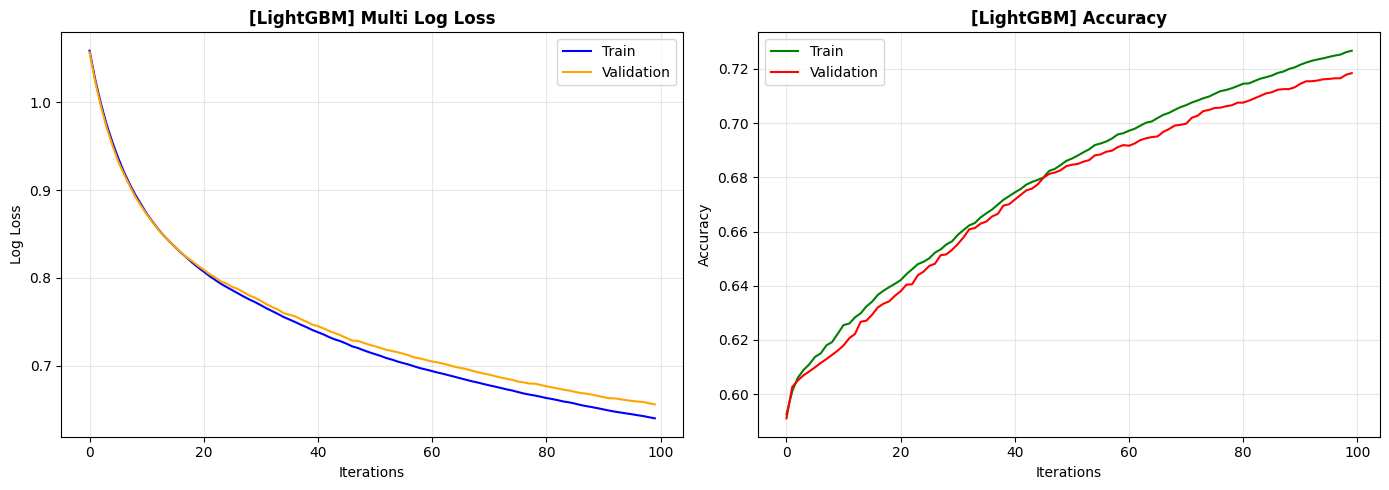

In [ ]:
# [Price Model] LightGBM 학습 곡선 시각화 (Optimized & Auto-Recovery v2)
# ModuleNotFoundError 해결을 위해 절대 경로 설정 강화
# 초기 100회 과정

import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# --- Auto-Recovery: Data Loading ---
if 'X_train_scaled_p' not in locals():
    print("ℹ️ Data variables not found. Running Data Load & Preprocessing (Auto-Recovery)...")
    
    # [Fix] 현재 작업 디렉토리 확인 및 경로 설정
    # 노트북이 실행되는 위치에 따라 상대 경로가 달라질 수 있으므로,
    # 프로젝트 루트를 찾거나 절대 경로로 접근 시도
    
    current_dir = Path(os.getcwd()) 
    print(f"Current Working Directory: {current_dir}")

    # 1. 'apps' 폴더가 있는 위치 찾기 (프로젝트 루트 찾기)
    project_root = current_dir
    while not (project_root / 'apps').exists():
        if project_root.parent == project_root: # 루트 도달
            break
        project_root = project_root.parent
            
    # 2. preprocessor.py가 있는 실제 경로 구성
    ml_src_path = project_root / 'apps/reco/models/price_model/ML/src'
    ml_src_path = ml_src_path.resolve()
    
    print(f"Target Source Path: {ml_src_path}")
    
    if str(ml_src_path) not in sys.path:
        sys.path.append(str(ml_src_path))
        print(f"Added to sys.path: {ml_src_path}")
    
    try:
        from preprocessor import PriceDataPreprocessor
        print("✅ Successfully imported PriceDataPreprocessor")
        
        # 1. Load Data (경로도 프로젝트 루트 기준)
        train_path = project_root / 'data/actual_transaction_price/월세_train(24.08~25.08).csv'
        test_path = project_root / 'data/actual_transaction_price/월세_test(25.09~25.10).csv'
        
        if train_path.exists() and test_path.exists():
            price_train = pd.read_csv(train_path)
            price_test = pd.read_csv(test_path)
            
            # 2. Initialize Preprocessor
            preprocessor = PriceDataPreprocessor()
            
            # 3. Create Target
            df_train = preprocessor.create_target(price_train)
            df_test = preprocessor.create_target(
                price_test, 
                train_stats={"gu_quantiles": preprocessor.train_gu_quantiles}
            )
            
            # 4. Advanced Feature Engineering
            df_train, df_test = preprocessor.advanced_feature_engineering(df_train, df_test)
            
            # 5. Select Features
            X_train_raw = df_train[preprocessor.candidate_features]
            y_train_p = df_train[preprocessor.target_name]
            X_test_raw = df_test[preprocessor.candidate_features]
            y_test_p = df_test[preprocessor.target_name]
            
            # 6. Prepare Tree Features
            X_train_scaled_p, _, X_test_scaled_p = preprocessor.prepare_tree_features(
                X_train_raw, X_test_raw, X_test_raw
            )
            print("✅ Data Loaded & Preprocessed successfully.")
        else:
            print(f"❌ Data files not found at: {train_path}")
            # Try relative path fallback just in case
            train_path = 'data/actual_transaction_price/월세_train(24.08~25.08).csv'
            print(f"   (Checking relative fallback: {os.path.abspath(train_path)})")
            raise FileNotFoundError("Data files missing.")

    except ImportError as e:
        print(f"❌ Import Error: {e}")
        print(f"Sys Path: {sys.path}")
        raise
    except Exception as e:
        print(f"❌ Data Load Error: {e}")
        raise

# --- Visualization Logic ---
try:
    print("🚀 [Price Model] LightGBM 학습 곡선 분석 시작 (Fast Mode)...")
    
    lgbm_viz = LGBMClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        n_jobs=-1,
        verbose=-1
    )
    
    lgbm_viz.fit(
        X_train_scaled_p, y_train_p, 
        eval_set=[(X_train_scaled_p, y_train_p), (X_test_scaled_p, y_test_p)], 
        eval_names=['Train', 'Validation'],
        eval_metric=['multi_logloss', 'multi_error']
    )
    
    results = lgbm_viz.evals_result_
    epochs = len(results['Train']['multi_logloss'])
    x_axis = range(0, epochs)
    
    train_loss = results['Train']['multi_logloss']
    val_loss = results['Validation']['multi_logloss']
    train_acc = [1 - x for x in results['Train']['multi_error']]
    val_acc = [1 - x for x in results['Validation']['multi_error']]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(x_axis, train_loss, label='Train', color='blue')
    axes[0].plot(x_axis, val_loss, label='Validation', color='orange')
    axes[0].set_title('[LightGBM] Multi Log Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlabel('Iterations')
    axes[0].set_ylabel('Log Loss')

    axes[1].plot(x_axis, train_acc, label='Train', color='green')
    axes[1].plot(x_axis, val_acc, label='Validation', color='red')
    axes[1].set_title('[LightGBM] Accuracy', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlabel('Iterations')
    axes[1].set_ylabel('Accuracy')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error in Visualization: {e}")

🚀 [Price Model] LightGBM 전체 학습 과정 시각화 시작...
✅ 학습 완료: 총 1928 Iterations 수행됨.
   최종 Validation Acc: 0.7863


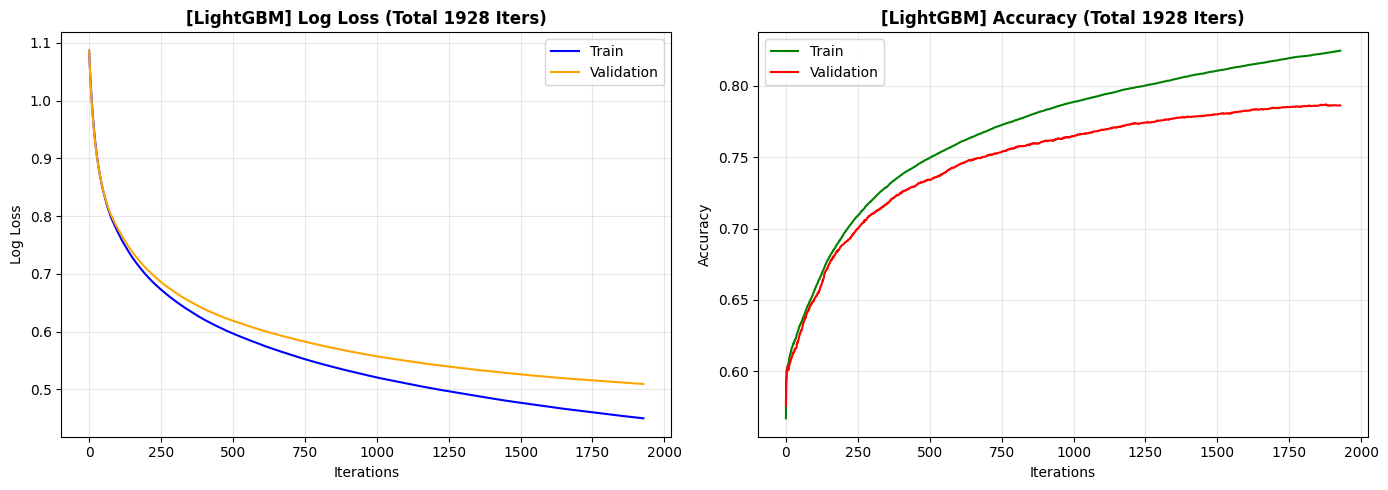

In [6]:
# [Price Model] LightGBM 전체 학습 과정 시각화 (Full Training with Fix)
# NameError 해결: early_stopping 임포트 추가

from lightgbm import LGBMClassifier, early_stopping
import matplotlib.pyplot as plt

try:
    print("🚀 [Price Model] LightGBM 전체 학습 과정 시각화 시작...")
    
    # 1. 모델 설정 (n_estimators를 표와 동일하게 2000으로 설정)
    lgbm_full_viz = LGBMClassifier(
        random_state=42,
        n_estimators=2000,  # 전체 과정 학습
        learning_rate=0.03, # 표와 동일한 학습률
        n_jobs=-1,
        verbose=-1
    )
    
    # 2. 학습 (Early Stopping 적용)
    lgbm_full_viz.fit(
        X_train_scaled_p, y_train_p, 
        eval_set=[(X_train_scaled_p, y_train_p), (X_test_scaled_p, y_test_p)], 
        eval_names=['Train', 'Validation'],
        eval_metric=['multi_logloss', 'multi_error'],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)] # 조기 종료
    )
    
    # 3. 결과 추출
    results = lgbm_full_viz.evals_result_
    epochs = len(results['Train']['multi_logloss'])
    x_axis = range(0, epochs)
    
    train_loss = results['Train']['multi_logloss']
    val_loss = results['Validation']['multi_logloss']
    
    # Error를 Accuracy로 변환
    train_acc = [1 - x for x in results['Train']['multi_error']]
    val_acc = [1 - x for x in results['Validation']['multi_error']]
    
    print(f"✅ 학습 완료: 총 {epochs} Iterations 수행됨.")
    print(f"   최종 Validation Acc: {val_acc[-1]:.4f}")

    # 4. 그래프 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Plot
    axes[0].plot(x_axis, train_loss, label='Train', color='blue')
    axes[0].plot(x_axis, val_loss, label='Validation', color='orange')
    axes[0].set_title(f'[LightGBM] Log Loss (Total {epochs} Iters)', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlabel('Iterations')
    axes[0].set_ylabel('Log Loss')

    # Accuracy Plot
    axes[1].plot(x_axis, train_acc, label='Train', color='green')
    axes[1].plot(x_axis, val_acc, label='Validation', color='red')
    axes[1].set_title(f'[LightGBM] Accuracy (Total {epochs} Iters)', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlabel('Iterations')
    axes[1].set_ylabel('Accuracy')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error in Visualization: {e}")